## Multiple Features

In [2]:
import os
import re
import ast
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from typing import Union, Dict, Optional, List

In [3]:
input_path="../data/prediction_zeynep_22/input_data/graphcast_ready_input_zeynep_22_graphcast_small.nc"
original_prediction_path="../data/prediction_zeynep_22/predictions/zeynep_22_prediction_graphcast_small.nc"

In [4]:
def plot_feature_grouped_heatmap(
    masked_folder: Union[str, os.PathLike],
    reference_path: Union[str, os.PathLike],
    group_x: str = "Pressure Levels",
    group_y: str = "Variable",
    region_lat: slice = slice(55.0, 53.0),
    region_lon: slice = slice(7.5, 10.5),
    title: str = "Δ Wind Speed – Grouped Heatmap",
    rename_map: Optional[Dict[str, str]] = None,
    order: Optional[Dict[str, List[str]]] = None
):
    def parse_filename_general(fname):
        name = fname.replace("masked_", "").replace(".nc", "")
        groups = {}

        stop_tokens = ["lev(", "reg", "t"]
        for token in stop_tokens:
            token_idx = name.find(token)
            if token_idx != -1:
                var_str = name[:token_idx].rstrip("_")
                name = name[token_idx:]
                break
        else:
            var_str = name
            name = ""

        try:
            parsed = ast.literal_eval(var_str)
            groups["Variable"] = "\n".join(parsed) if isinstance(parsed, tuple) else parsed
        except Exception:
            groups["Variable"] = var_str

        group_patterns = {
            "Pressure Levels": r"lev\((.*?)\)",
            "Region": r"reg(\(.*?\)|[A-Za-z0-9_]+)",
            "Time Step": r"t([0-9\-]+|none)"
        }

        for key, pattern in group_patterns.items():
            m = re.search(pattern, name)
            if m:
                groups[key] = m.group(1)

        return groups

    def mean_wind_speed(ds):
        u10 = ds["10m_u_component_of_wind"].squeeze()
        v10 = ds["10m_v_component_of_wind"].squeeze()
        wind_speed = np.sqrt(u10**2 + v10**2)
        return wind_speed.sel(lat=region_lat, lon=region_lon).mean().item()

    # Load reference mean wind speed
    reference_ds = xr.open_dataset(reference_path)
    reference_mean = mean_wind_speed(reference_ds)

    records = []

    # Loop through masked files
    for fname in sorted(os.listdir(masked_folder)):
        if not fname.endswith(".nc"):
            continue

        groups = parse_filename_general(fname)
        if group_x not in groups or group_y not in groups:
            continue

        x_val = rename_map.get(groups[group_x], groups[group_x]) if rename_map else groups[group_x]
        y_val = rename_map.get(groups[group_y], groups[group_y]) if rename_map else groups[group_y]

        ds = xr.open_dataset(os.path.join(masked_folder, fname))
        value = mean_wind_speed(ds)
        delta = value - reference_mean
        records.append((y_val, x_val, delta))

    if not records:
        raise ValueError("No valid data records were parsed. Check filename patterns and group names.")

    df = pd.DataFrame(records, columns=[group_y, group_x, "Δ Wind Speed"])

    if order:
        if group_y in order:
            df[group_y] = pd.Categorical(df[group_y], categories=order[group_y], ordered=True)
        if group_x in order:
            df[group_x] = pd.Categorical(df[group_x], categories=order[group_x], ordered=True)

    pivot_df = df.pivot_table(index=group_y, columns=group_x, values="Δ Wind Speed", aggfunc="mean")

    fig, ax = plt.subplots(figsize=(14, 8))
    im = ax.imshow(pivot_df.values, cmap="coolwarm", vmin=-np.abs(pivot_df.values).max(), vmax=np.abs(pivot_df.values).max())

    ax.set_xticks(np.arange(pivot_df.shape[1]))
    ax.set_yticks(np.arange(pivot_df.shape[0]))
    ax.set_xticklabels(pivot_df.columns)
    ax.set_yticklabels(pivot_df.index)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    for i in range(pivot_df.shape[0]):
        for j in range(pivot_df.shape[1]):
            val = pivot_df.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:.2f}", ha="center", va="center", color="black")

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Δ Wind Speed (m/s)")

    ax.set_title(title)
    ax.set_xlabel(group_x)
    ax.set_ylabel(group_y)
    plt.tight_layout()
    plt.show()


/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_22541/10045735.py:53: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  reference_ds = xr.open_dataset(reference_path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_22541/10045735.py:70: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(os.path.join(masked_folder, fname))
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_22541/10045735.py:70: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(os.path.join(masked_folder, fnam

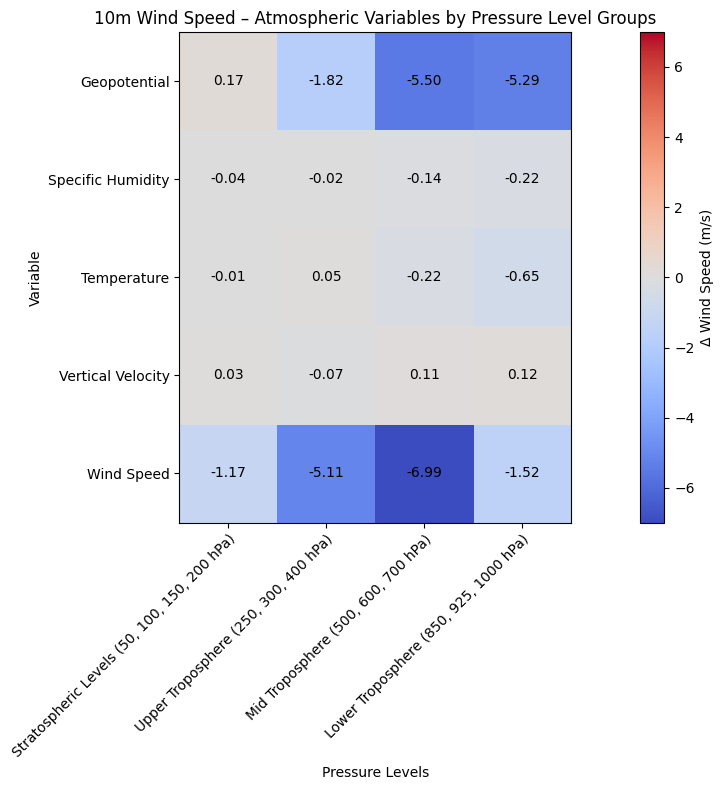

In [21]:
rename_map = {
    "geopotential": "Geopotential",
    "temperature": "Temperature",
    "specific_humidity": "Specific Humidity",
    # "u_component_of_wind": "U Wind",
    # "v_component_of_wind": "V Wind",
    "u_component_of_wind\nv_component_of_wind": "Wind Speed",
    "vertical_velocity": "Vertical Velocity",

    "50, 100, 150, 200": "Stratospheric Levels (50, 100, 150, 200 hPa)",
    "250, 300, 400": "Upper Troposphere (250, 300, 400 hPa)",
    "500, 600, 700": "Mid Troposphere (500, 600, 700 hPa)",
    "850, 925, 1000": "Lower Troposphere (850, 925, 1000 hPa)"
}

plot_feature_grouped_heatmap(
    masked_folder="../data/feature_occlusion/pressure_level_groups_atmospheric_variables",
    reference_path=original_prediction_path,
    group_x="Pressure Levels",
    group_y="Variable",
    title="10m Wind Speed – Atmospheric Variables by Pressure Level Groups",
    rename_map=rename_map,
    order={
        "Pressure Levels": [
            "Stratospheric Levels (50, 100, 150, 200 hPa)",
            "Upper Troposphere (250, 300, 400 hPa)",
            "Mid Troposphere (500, 600, 700 hPa)",
            "Lower Troposphere (850, 925, 1000 hPa)"
        ],
    }
)


/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_32308/10045735.py:53: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  reference_ds = xr.open_dataset(reference_path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_32308/10045735.py:70: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(os.path.join(masked_folder, fname))
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_32308/10045735.py:70: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(os.path.join(masked_folder, fnam

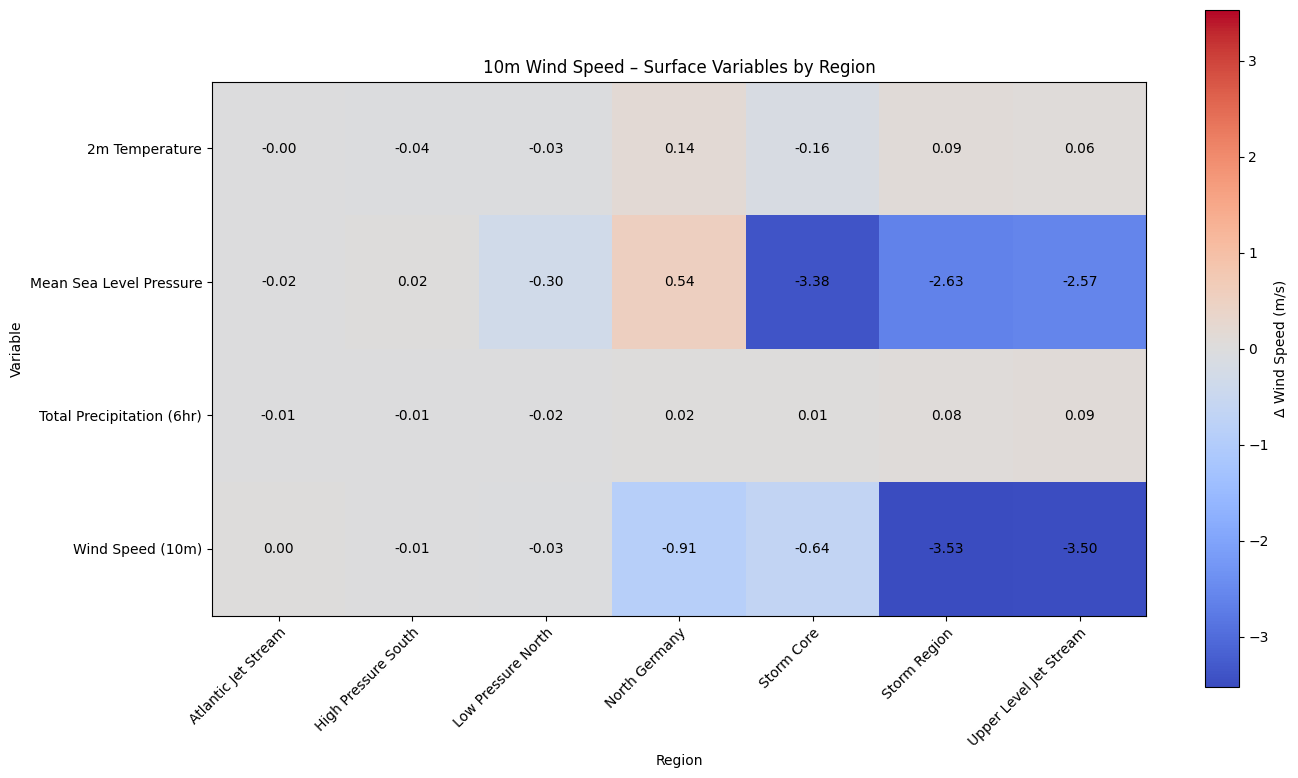

In [4]:
rename_map = {
    "2m_temperature_levnone": "2m Temperature",
    "mean_sea_level_pressure_levnone": "Mean Sea Level Pressure",
    "total_precipitation_6hr_levnone": "Total Precipitation (6hr)",
    "('10m_u_component_of_wind', '10m_v_component_of_wind')_levnone": "Wind Speed (10m)",

    "atlantic_jet_stream_tnone": "Atlantic Jet Stream",
    "high_pressure_south_tnone": "High Pressure South",
    "low_pressure_north_tnone": "Low Pressure North",
    "north_germany_tnone": "North Germany",
    "storm_core_10utc_tnone": "Storm Core at 10 UTC",
    "storm_core_16utc_tnone": "Storm Core at 16 UTC",
    "('storm_core_10utc', 'storm_core_16utc')": "Storm Core 10 and 16 UTC",
    "storm_region_tnone": "Storm Region",
    "storm_core_tnone": "Storm Core",
    "dynamic_uljs_tnone": "Upper Level Jet Stream"
}

plot_feature_grouped_heatmap(
    masked_folder="../data/feature_occlusion/regions_surface_variables",
    reference_path=original_prediction_path,
    group_x="Region",
    title="10m Wind Speed – Surface Variables by Region",
    rename_map=rename_map
)


/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_58297/10045735.py:53: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  reference_ds = xr.open_dataset(reference_path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_58297/10045735.py:70: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(os.path.join(masked_folder, fname))
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_58297/10045735.py:70: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(os.path.join(masked_folder, fnam

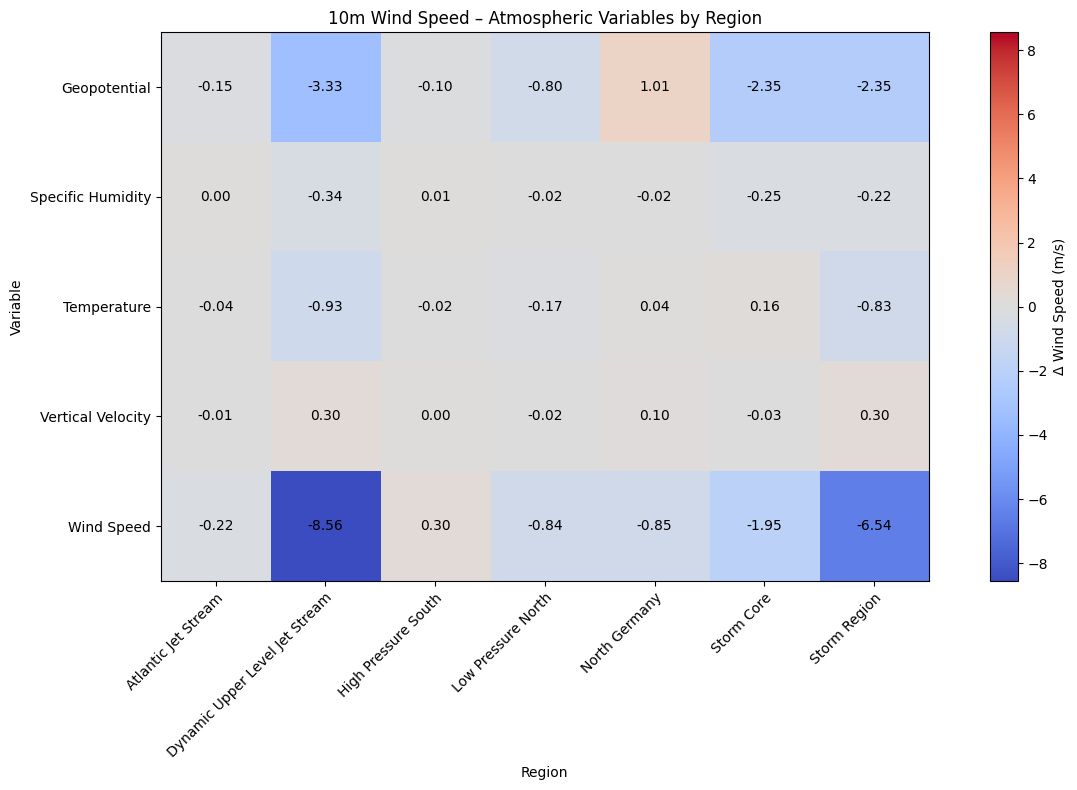

In [5]:
rename_map = {
    "geopotential_levnone": "Geopotential",
    "temperature_levnone": "Temperature",
    "specific_humidity_levnone": "Specific Humidity",
    "('u_component_of_wind', 'v_component_of_wind')_levnone": "Wind Speed",
    "vertical_velocity_levnone": "Vertical Velocity",
    "storm_core_tnone": "Storm Core",

    "atlantic_jet_stream_tnone": "Atlantic Jet Stream",
    "upper_level_jet_stream_tnone": "Upper Level Jet Stream",
    "high_pressure_south_tnone": "High Pressure South",
    "low_pressure_north_tnone": "Low Pressure North",
    "north_germany_tnone": "North Germany",
    "storm_region_tnone": "Storm Region",
    "dynamic_uljs_tnone": "Dynamic Upper Level Jet Stream"
}

plot_feature_grouped_heatmap(
    masked_folder="../data/feature_occlusion/regions_atmospheric_variables",
    reference_path=original_prediction_path,
    group_x="Region",
    title="10m Wind Speed – Atmospheric Variables by Region",
    rename_map=rename_map,
)


/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_58297/10045735.py:53: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  reference_ds = xr.open_dataset(reference_path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_58297/10045735.py:70: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(os.path.join(masked_folder, fname))
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_58297/10045735.py:70: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(os.path.join(masked_folder, fnam

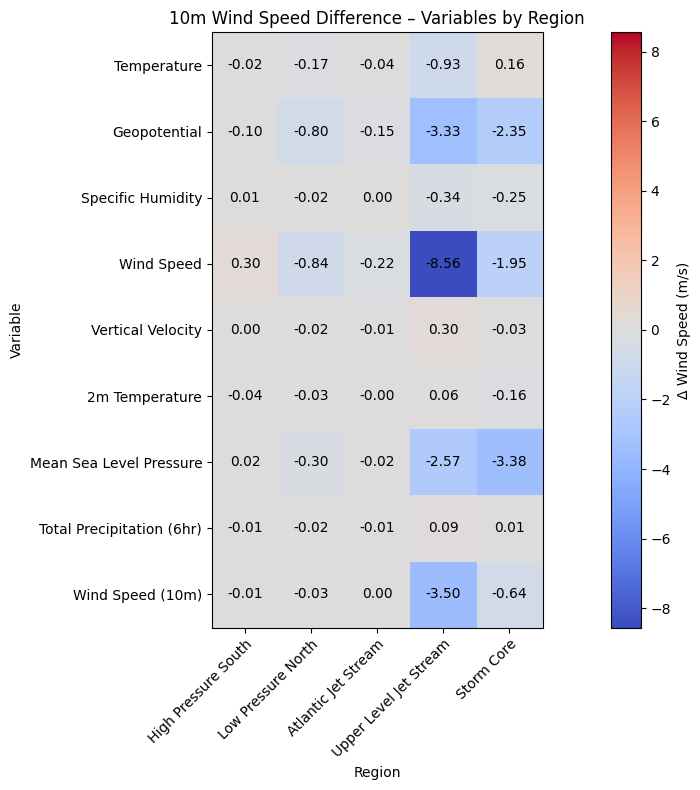

In [21]:
rename_map = {
    # Surface Variables
    "2m_temperature_levnone": "2m Temperature",
    "mean_sea_level_pressure_levnone": "Mean Sea Level Pressure",
    "total_precipitation_6hr_levnone": "Total Precipitation (6hr)",
    "('10m_u_component_of_wind', '10m_v_component_of_wind')_levnone": "Wind Speed (10m)",

    # Atmospheric Variables
    "geopotential_levnone": "Geopotential",
    "temperature_levnone": "Temperature",
    "specific_humidity_levnone": "Specific Humidity",
    "('u_component_of_wind', 'v_component_of_wind')_levnone": "Wind Speed",
    "vertical_velocity_levnone": "Vertical Velocity",

    # Regions
    "atlantic_jet_stream_tnone": "Atlantic Jet Stream",
    "high_pressure_south_tnone": "High Pressure South",
    "low_pressure_north_tnone": "Low Pressure North",
    "dynamic_uljs_tnone": "Upper Level Jet Stream",
    "storm_core_tnone": "Storm Core",
    "north_germany_tnone": "North Germany",
}

order = {
    "Region": [
        "High Pressure South",
        "Low Pressure North",
        "Atlantic Jet Stream",
        "Upper Level Jet Stream",
        "Storm Core",
        "North Germany"
    ],
    "Variable": [
        "Temperature",
        "Geopotential",
        "Specific Humidity",
        "Wind Speed",
        "Vertical Velocity",

        "2m Temperature",
        "Mean Sea Level Pressure",
        "Total Precipitation (6hr)",
        "Wind Speed (10m)"
    ]
}

plot_feature_grouped_heatmap(
    masked_folder="../data/feature_occlusion/region_variables_heatmap_bt",
    reference_path=original_prediction_path,
    group_x="Region",
    title="10m Wind Speed Difference – Variables by Region",
    rename_map=rename_map,
    order=order
)

/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_77101/10045735.py:53: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  reference_ds = xr.open_dataset(reference_path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_77101/10045735.py:70: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(os.path.join(masked_folder, fname))
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_77101/10045735.py:70: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(os.path.join(masked_folder, fnam

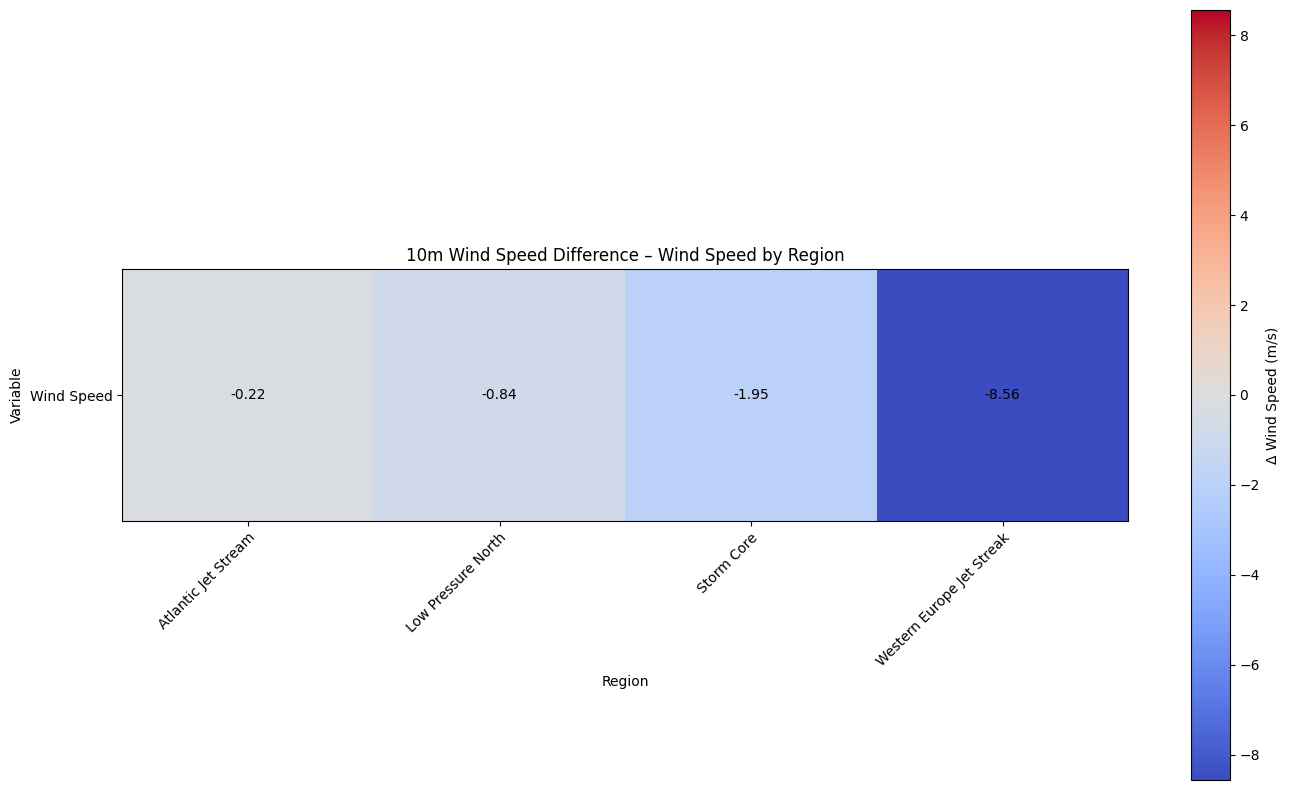

In [6]:
rename_map = {
    # Surface Variables
    "2m_temperature_levnone": "2m Temperature",
    "mean_sea_level_pressure_levnone": "Mean Sea Level Pressure",
    "total_precipitation_6hr_levnone": "Total Precipitation (6hr)",
    "('10m_u_component_of_wind', '10m_v_component_of_wind')_levnone": "Wind Speed (10m)",

    # Atmospheric Variables
    "geopotential_levnone": "Geopotential",
    "temperature_levnone": "Temperature",
    "specific_humidity_levnone": "Specific Humidity",
    "('u_component_of_wind', 'v_component_of_wind')_levnone": "Wind Speed",
    "vertical_velocity_levnone": "Vertical Velocity",

    # Regions
    "atlantic_jet_stream_tnone": "Atlantic Jet Stream",
    "high_pressure_south_tnone": "High Pressure South",
    "low_pressure_north_tnone": "Low Pressure North",
    "dynamic_uljs_tnone": "Western Europe Jet Streak",
    "storm_core_tnone": "Storm Core",
}

order = {
    "Region": [
        "Atlantic Jet Stream",
        "Low Pressure North",
        "Storm Core",
        "Western Europe Jet Streak"
    ],
    "Variable": [
        "Wind Speed"
    ]
}

plot_feature_grouped_heatmap(
    masked_folder="../data/feature_occlusion/region_variables_heatmap_bt",
    reference_path=original_prediction_path,
    group_x="Region",
    title="10m Wind Speed Difference – Wind Speed by Region",
    rename_map=rename_map,
    order=order
)

/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_32308/10045735.py:53: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  reference_ds = xr.open_dataset(reference_path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_32308/10045735.py:70: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(os.path.join(masked_folder, fname))
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_32308/10045735.py:70: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(os.path.join(masked_folder, fnam

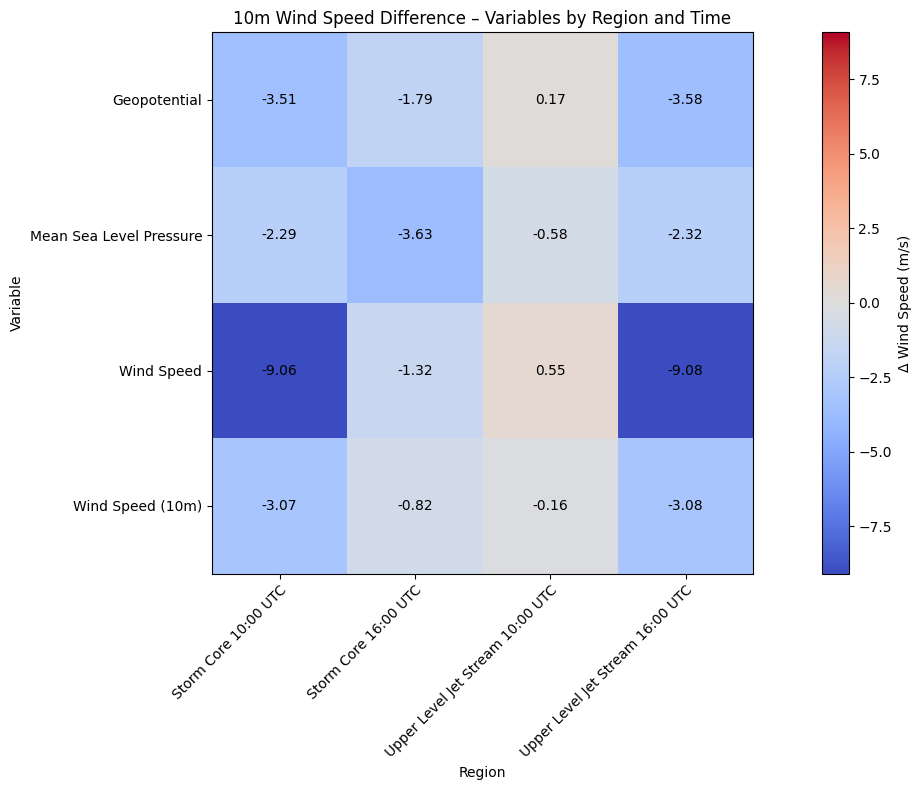

In [17]:
rename_map = {
    # Surface Variables
    "mean_sea_level_pressure_levnone": "Mean Sea Level Pressure",
    "('10m_u_component_of_wind', '10m_v_component_of_wind')_levnone": "Wind Speed (10m)",

    # Atmospheric Variables
    "geopotential_levnone": "Geopotential",
    "('u_component_of_wind', 'v_component_of_wind')_levnone": "Wind Speed",

    # Regions
    "dynamic_uljs_t0": "Upper Level Jet Stream 10:00 UTC",
    "dynamic_uljs_t1": "Upper Level Jet Stream 16:00 UTC",
    "storm_core_t0": "Storm Core 10:00 UTC",
    "storm_core_t1": "Storm Core 16:00 UTC",
}

plot_feature_grouped_heatmap(
    masked_folder="../data/feature_occlusion/selected_regions_variables_time",
    reference_path=original_prediction_path,
    group_x="Region",
    title="10m Wind Speed Difference – Variables by Region and Time",
    rename_map=rename_map,
)

In [9]:
def plot_feature_grouped_heatmap_special(
    masked_folder: Union[str, os.PathLike],
    reference_path: Union[str, os.PathLike],
    group_x: str = "Pressure Levels",
    group_y: str = "Variable",
    region_lat: slice = slice(55.0, 53.0),
    region_lon: slice = slice(7.5, 10.5),
    title: str = "Δ Wind Speed – Grouped Heatmap",
    rename_map: Optional[Dict[str, str]] = None,
    order: Optional[Dict[str, List[str]]] = None
):
    def parse_filename_general(fname):
        name = fname.replace("masked_", "").replace(".nc", "")
        groups = {}

        # Match variable block at the beginning (before lev/reg/t)
        var_match = re.match(r"^(.*?)(?=_lev|_reg|_t)", name)
        var_str = var_match.group(1) if var_match else name

        try:
            parsed = ast.literal_eval(var_str)
            groups["Variable"] = "\n".join(parsed) if isinstance(parsed, tuple) else parsed
        except Exception:
            groups["Variable"] = var_str

        group_patterns = {
            "Pressure Levels": r"_lev(\d+)",
            "Region": r"_reg([A-Za-z0-9_]+)",
            "Time Step": r"_t([A-Za-z0-9_\-]+)"
        }

        for key, pattern in group_patterns.items():
            m = re.search(pattern, name)
            if m:
                groups[key] = m.group(1)

        return groups


    def mean_wind_speed(ds):
        u10 = ds["10m_u_component_of_wind"].squeeze()
        v10 = ds["10m_v_component_of_wind"].squeeze()
        wind_speed = np.sqrt(u10**2 + v10**2)
        return wind_speed.sel(lat=region_lat, lon=region_lon).mean().item()

    # Load reference mean wind speed
    reference_ds = xr.open_dataset(reference_path)
    reference_mean = mean_wind_speed(reference_ds)

    records = []

    # Loop through masked files
    for fname in sorted(os.listdir(masked_folder)):
        if not fname.endswith(".nc"):
            continue

        groups = parse_filename_general(fname)
        if group_x not in groups or group_y not in groups:
            continue

        x_val = rename_map.get(groups[group_x], groups[group_x]) if rename_map else groups[group_x]
        y_val = rename_map.get(groups[group_y], groups[group_y]) if rename_map else groups[group_y]

        ds = xr.open_dataset(os.path.join(masked_folder, fname))
        value = mean_wind_speed(ds)
        delta = value - reference_mean
        records.append((y_val, x_val, delta))

    if not records:
        raise ValueError("No valid data records were parsed. Check filename patterns and group names.")

    df = pd.DataFrame(records, columns=[group_y, group_x, "Δ Wind Speed"])

    if order:
        if group_y in order:
            df[group_y] = pd.Categorical(df[group_y], categories=order[group_y], ordered=True)
        if group_x in order:
            df[group_x] = pd.Categorical(df[group_x], categories=order[group_x], ordered=True)

    pivot_df = df.pivot_table(index=group_y, columns=group_x, values="Δ Wind Speed", aggfunc="mean")

    fig, ax = plt.subplots(figsize=(14, 8))
    im = ax.imshow(pivot_df.values, cmap="coolwarm", vmin=-np.abs(pivot_df.values).max(), vmax=np.abs(pivot_df.values).max())

    ax.set_xticks(np.arange(pivot_df.shape[1]))
    ax.set_yticks(np.arange(pivot_df.shape[0]))
    ax.set_xticklabels(pivot_df.columns)
    ax.set_yticklabels(pivot_df.index)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    for i in range(pivot_df.shape[0]):
        for j in range(pivot_df.shape[1]):
            val = pivot_df.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:.2f}", ha="center", va="center", color="black")

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Δ Wind Speed (m/s)")

    ax.set_title(title)
    ax.set_xlabel(group_x)
    ax.set_ylabel(group_y)
    plt.tight_layout()
    plt.show()

/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_24308/2836189969.py:47: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  reference_ds = xr.open_dataset(reference_path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_24308/2836189969.py:64: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(os.path.join(masked_folder, fname))
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_24308/2836189969.py:64: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(os.path.join(masked_folder

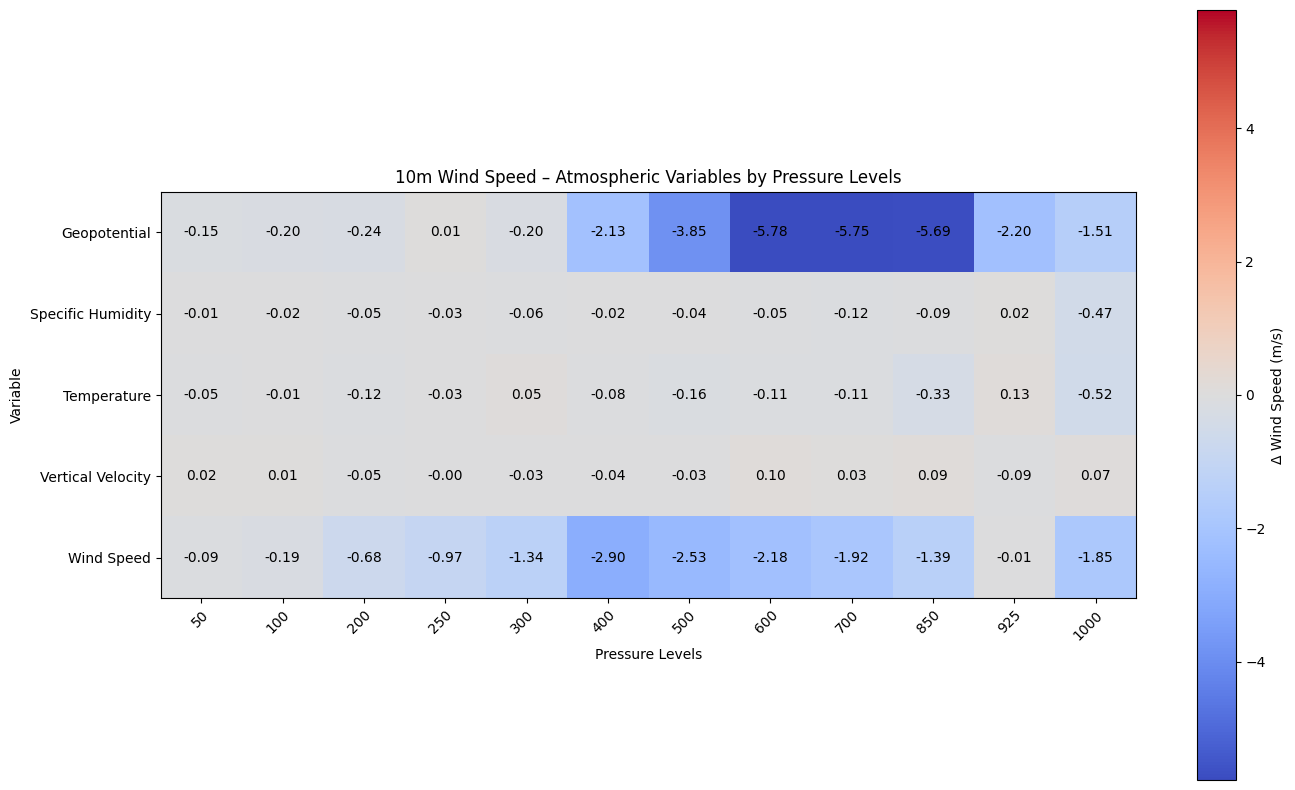

In [5]:
rename_map = {
    "geopotential": "Geopotential",
    "temperature": "Temperature",
    "specific_humidity": "Specific Humidity",
    "u_component_of_wind\nv_component_of_wind": "Wind Speed",
    "vertical_velocity": "Vertical Velocity",
}

order = {
    "Pressure Levels": [
        "50",
        "100",
        "150 ",
        "200",
        "250",
        "300",
        "400",
        "500",
        "600",  
        "700",  
        "850",
        "925",
        "1000"
    ],
}

plot_feature_grouped_heatmap_special(
    masked_folder="../data/feature_occlusion/atmospheric_variables_levels",
    reference_path=original_prediction_path,
    group_x="Pressure Levels",
    group_y="Variable",
    title="10m Wind Speed – Atmospheric Variables by Pressure Levels",
    rename_map=rename_map,
    order=order
)


/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_58297/2836189969.py:47: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  reference_ds = xr.open_dataset(reference_path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_58297/2836189969.py:64: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(os.path.join(masked_folder, fname))
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_58297/2836189969.py:64: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(os.path.join(masked_folder

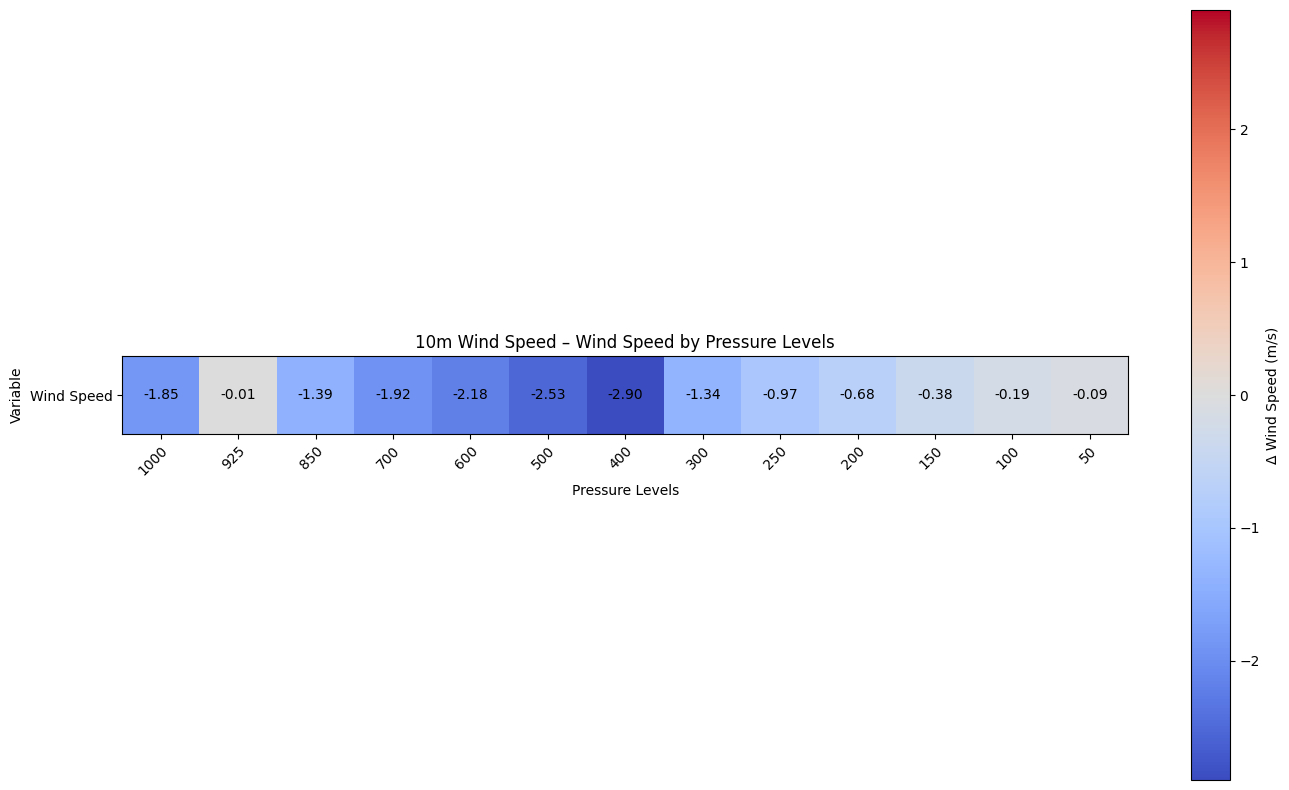

In [14]:
rename_map = {
    "geopotential": "Geopotential",
    "temperature": "Temperature",
    "specific_humidity": "Specific Humidity",
    "u_component_of_wind\nv_component_of_wind": "Wind Speed",
    "vertical_velocity": "Vertical Velocity",
}

order = {
    "Pressure Levels": [
        "1000",
        "925",
        "850",
        "700",      
        "600",
        "500",
        "400",
        "300",
        "250",
        "200",
        "150",
        "100",
        "50"
    ],
    "Variable": [
        "Wind Speed",
    ]
}

plot_feature_grouped_heatmap_special(
    masked_folder="../data/feature_occlusion/atmospheric_variables_levels",
    reference_path=original_prediction_path,
    group_x="Pressure Levels",
    group_y="Variable",
    title="10m Wind Speed – Wind Speed by Pressure Levels",
    rename_map=rename_map,
    order=order
)

In [18]:
import os
import re
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from typing import Union, Optional, Dict

def plot_region_level_heatmap(
    masked_folder: Union[str, os.PathLike],
    reference_path: Union[str, os.PathLike],
    region_lat: slice = slice(55.0, 53.0),
    region_lon: slice = slice(7.5, 10.5),
    title: str = "Δ Wind Speed – Region vs Pressure Level",
    rename_map: Optional[Dict[str, str]] = None,
    level_order: Optional[list] = None,
    region_order: Optional[list] = None
):
    def parse_filename(fname):
        name = os.path.splitext(fname)[0]

        groups = {}
        level_match = re.search(r"_lev([0-9]+|none)", name)
        region_match = re.search(r"_reg([A-Za-z0-9_]+)", name)

        if level_match:
            groups["Level"] = level_match.group(1)
        if region_match:
            groups["Region"] = region_match.group(1)

        return groups

    def mean_value(ds):
        # Compute 10m wind speed
        if "10m_u_component_of_wind" in ds and "10m_v_component_of_wind" in ds:
            u10 = ds["10m_u_component_of_wind"].squeeze()
            v10 = ds["10m_v_component_of_wind"].squeeze()
            wind_speed = np.sqrt(u10**2 + v10**2)
            return wind_speed.sel(lat=region_lat, lon=region_lon).mean().item()
        else:
            raise ValueError("Wind components not found in dataset.")

    # Reference wind speed (should always contain 10m_u and 10m_v)
    reference_ds = xr.open_dataset(reference_path)
    reference_mean = mean_value(reference_ds)

    records = []

    for fname in sorted(os.listdir(masked_folder)):
        if not fname.endswith(".nc"):
            continue

        groups = parse_filename(fname)
        if "Region" not in groups or "Level" not in groups:
            continue

        level = groups["Level"]
        region = groups["Region"]

        level = rename_map.get(level, level) if rename_map else level
        region = rename_map.get(region, region) if rename_map else region

        try:
            ds = xr.open_dataset(os.path.join(masked_folder, fname))
            value = mean_value(ds)
            delta = value - reference_mean
            records.append((region, level, delta))
        except Exception as e:
            print(f"⚠️ Skipped {fname} due to: {e}")
            continue

    if not records:
        raise ValueError("No valid data records parsed. Check filename patterns and contents.")

    df = pd.DataFrame(records, columns=["Region", "Level", "Δ Wind Speed"])

    if level_order:
        df["Level"] = pd.Categorical(df["Level"], categories=level_order, ordered=True)
    if region_order:
        df["Region"] = pd.Categorical(df["Region"], categories=region_order, ordered=True)

    pivot_df = df.pivot_table(index="Region", columns="Level", values="Δ Wind Speed", aggfunc="mean")

    fig, ax = plt.subplots(figsize=(14, 8))
    im = ax.imshow(
        pivot_df.values,
        cmap="coolwarm",
        vmin=-6,
        vmax=6
    )

    ax.set_xticks(np.arange(pivot_df.shape[1]))
    ax.set_yticks(np.arange(pivot_df.shape[0]))
    ax.set_xticklabels(pivot_df.columns)
    ax.set_yticklabels(pivot_df.index)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    for i in range(pivot_df.shape[0]):
        for j in range(pivot_df.shape[1]):
            val = pivot_df.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:.2f}", ha="center", va="center", color="black")

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Δ Wind Speed (m/s)")

    ax.set_title(title)
    ax.set_xlabel("Pressure Level")
    ax.set_ylabel("Region")
    plt.tight_layout()
    plt.show()



/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_58297/3482890923.py:44: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  reference_ds = xr.open_dataset(reference_path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_58297/3482890923.py:64: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(os.path.join(masked_folder, fname))
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_58297/3482890923.py:64: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(os.path.join(masked_folder

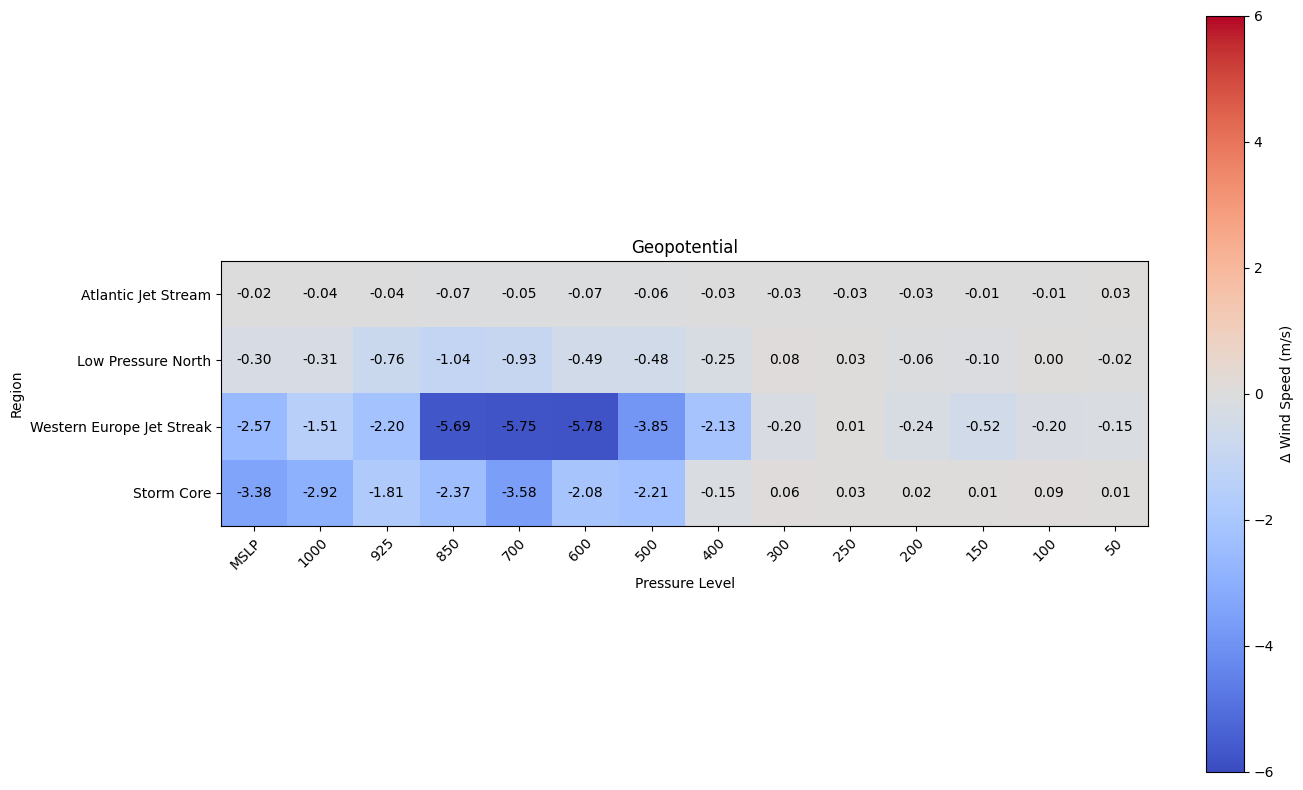

In [22]:
rename_map = {
    "none": "MSLP",  # Surface-level variable
    "atlantic_jet_stream_tnone": "Atlantic Jet Stream",
    "dynamic_uljs_tnone": "Western Europe Jet Streak",
    "high_pressure_south_tnone": "High Pressure South",
    "low_pressure_north_tnone": "Low Pressure North",
    "storm_core_tnone": "Storm Core",
    "storm_region_tnone": "Storm Region",
    "north_germany": "North Germany"
}

level_order = ["MSLP", "1000", "925", "850", "700", "600", "500", "400", "300", "250", "200", "150", "100", "50"]

plot_region_level_heatmap(
    masked_folder="../data/feature_occlusion/geopotential_levels_regions",
    reference_path=original_prediction_path,
    title="Geopotential",
    rename_map=rename_map,
    level_order=level_order,
        region_order=[
        "Atlantic Jet Stream",
        "Low Pressure North",
        "Western Europe Jet Streak",
        "Storm Core",
    ]
)



/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_58297/3482890923.py:44: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  reference_ds = xr.open_dataset(reference_path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_58297/3482890923.py:64: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(os.path.join(masked_folder, fname))
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_58297/3482890923.py:64: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(os.path.join(masked_folder

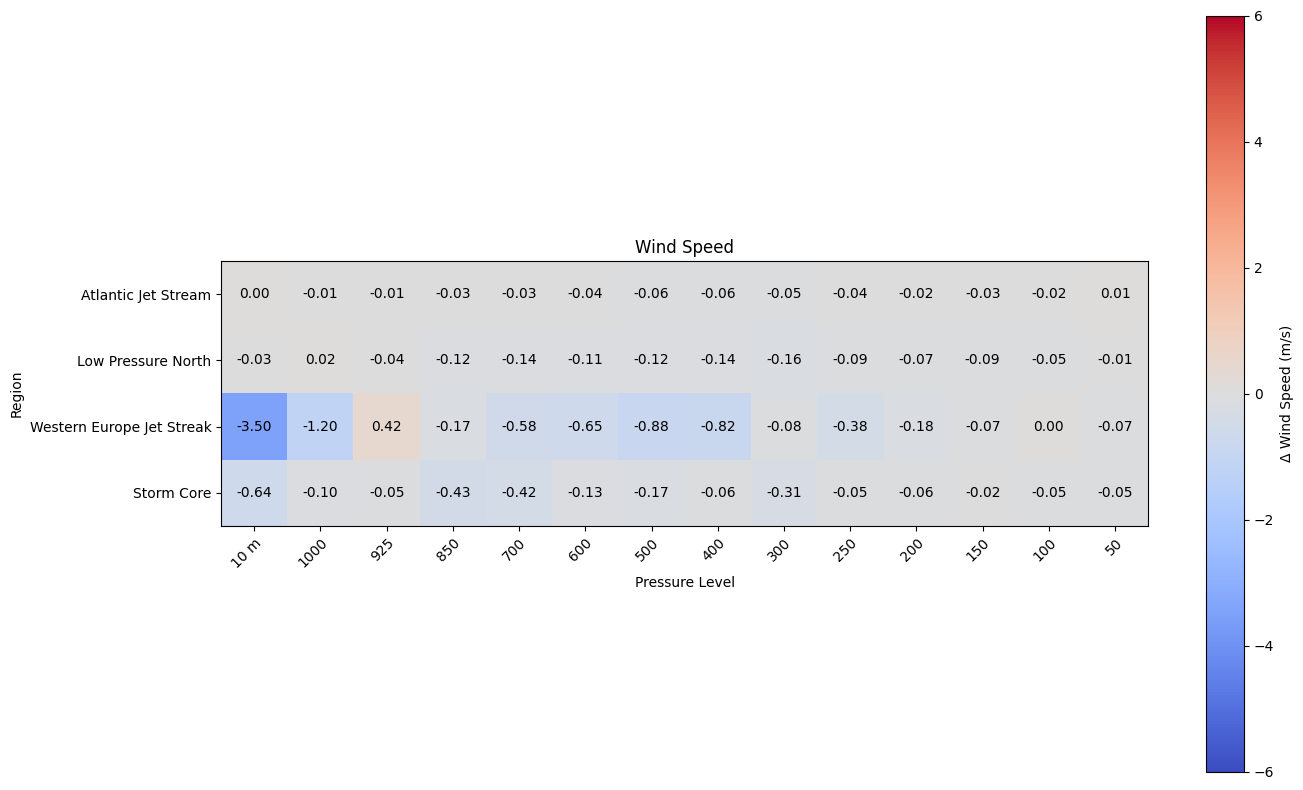

In [23]:
rename_map = {
    "none": "10 m",  # Surface-level variable
    "atlantic_jet_stream_tnone": "Atlantic Jet Stream",
    "dynamic_uljs_tnone": "Western Europe Jet Streak",
    "high_pressure_south_tnone": "High Pressure South",
    "low_pressure_north_tnone": "Low Pressure North",
    "storm_core_tnone": "Storm Core",
    "storm_region_tnone": "Storm Region",
    "north_germany": "North Germany"
}

level_order = ["10 m", "1000", "925", "850", "700", "600", "500", "400", "300", "250", "200", "150", "100", "50"]

plot_region_level_heatmap(
    masked_folder="../data/feature_occlusion/wind_levels_regions",
    reference_path=original_prediction_path,
    title="Wind Speed",
    rename_map=rename_map,
    level_order=level_order,
    region_order=[
        "Atlantic Jet Stream",
        "Low Pressure North",
        "Western Europe Jet Streak",
        "Storm Core",
    ]
)